# S1 2024 COMPSCI 714 - Tutorial 4: Sequence Data, Recurrent Neural Network (RNN) and Transformer

Welcome to Tutorial 4! This tutorial covers basics of sequential data and RNNs, as well as how to use some pre-trained models based on the Transformer architecture with the Hugging Face Transfomers library. 

Disclaimer/Copyright: some parts of the code and text used in this Notebook is directly reused or adapted from Aurélien Géron's notebooks https://github.com/ageron/handson-ml3/blob/main/15_processing_sequences_using_rnns_and_cnns.ipynb, https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb and his book "Hands-on Machine Learning with Scikit-Learn, Keras and Tensorflow, Ed.3", more particulary from Chapters 15 and 16.

This tutorial will be mainly using Keras/TensorFlow, but we provide a link to a PyTorch tutorial to perform a similar task using a RNN. 

In [2]:
import sys
import tensorflow as tf
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

## Prelude: Using a GPU

GPU stands for Graphics Processing Unit. This is a specialised piece of hardware used to accelerate computer graphics and image processing on your computer. They are good at running a lot of operations in parallel, making them particularly interesting to accelerate computations in ML and AI. You will learn more about Parallel/GPU computing in a guest lecture after the mid-semester break. 

For this tutorial, it is preferable to use a GPU to accelerate calculations as we will train more complicated types of neural networks for a longer amount of epochs, especially in Parts II and III. The easiest way to do this is to run this notebook in Colab and select: Runtime > Change runtime and select a GPU hardware accelerator.

If you have a *CUDA enabled* GPU ([list of NVIDIA Cuda enabled GPUs](https://developer.nvidia.com/cuda-gpus)) on your machine, you can use it to accelerate calculations directly locally. Note that only a range of NVIDIA GPUs are compatible with CUDA and can be used with TensorFlow. GPUs from other manufacturers (e.g., AMD, Intel) are not easy to setup for ML and AI yet. Therefore, we recommend you to use Colab if you do not have a NVIDIA CUDA GPU, or if you prefer not to use it for this purpose.  
You can follow the directives on the [TensorFlow installation guide](https://www.tensorflow.org/install/pip) to allow TensorFlow to use your GPU. Once this is done, you can verify that TensorFlow "sees" your GPU by running the following cell.

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


This should display "Num GPUs Available:  1" if you have a GPU available and setup for use with TensorFlow, else "Num GPUs Available:  0". 

If you want to use a CUDA enabled GPU with PyTorch, you can follow the instrcutions in this [Medium blog post](https://medium.com/ai%C2%B3-theory-practice-business/use-gpu-in-your-pytorch-code-676a67faed09).

If you run the code locally on your machine and you do not have a CUDA GPU available (or not correctly setup), the code will run on your CPU. 

In [3]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")

No GPU was detected. Neural nets can be very slow without a GPU.


Each part of the tutorial is independent (you just need to run the imports above first). We recommend you start with Part I as it covers time series with several flavors of RNNs, and it is possible to run it on a CPU quite quickly. Parts II involve using a RNN to perform some text generation. Training the models in this part will take a very long time on a CPU, and even some times on a GPU. You will have the possibility to directly download the trained model to play with text generation without training the model yourself. 

## I. Time series forecasting with RNNs

Time series are a type of sequential data. Sequential data refers to data that is ordered, where each element is associated with a specific position or time step within a sequence. When the data consists in a series of data points indexed or organised in time order, we talk about time series. Other forms of data such as text, videos or even DNA are also sequential as the order in which letters, words, video frames (i.e., images) or nucleotides appear is important to make sense of the data. With sequential data, the order of the data is an essential piece of information that the model must capture. 

### I.1. Chicago's Transit Time Series dataset

For the first part of this tutorial, we will use some RNNs to model and make predictions on a time series. We will use the ridership data from the ageron/data project. It originally comes from Chicago's Transit Authority, and was downloaded from the [Chicago's Data Portal](https://data.cityofchicago.org/Transportation/CTA-Ridership-Daily-Boarding-Totals/6iiy-9s97/about_data). You can read more about the dataset at the previous link. The dataset contains numbers of ridership (i.e., boarding) for bus and rail per day since 2001 in Chicago, USA. First, we will try to build a model to forecast the ridership numbers for the next day.  
Run the following cell to download the dataset from ageron/data.

In [ ]:
tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".",
    extract=True
)

#### I.1.i. Loading and cleaning the dataset

Let's load and clean the data using pandas. 

In [16]:
path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

First, the values were sorted with respect to the date. Then, the `total` column was removed as it contains redundant information with the `bus` and `rail` columns. FInally, if you look at the data before cleaning, you will notice that some rows (i.e., days) are duplicated. Therefore, the `drop_duplicates()` method was used to drop these (i.e., only one row is kept for each duplicated data). 

#### I.1.ii. Exploring the data (briefly)

Let's visualise the first 5 rows of the dataset.

In [5]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


The `date` column contains the date, the `day_type` column contains a code describing the type of day (W = Weekday, A = Saturday, U = Sunday/Holiday) and the `bus` and `rail` colmuns contain the number of passengers who boarded respectfully the bus or train in Chicago that day. For example, on the 1st of January 2001, which was a Sunday or Public Holiday, 297 192 people boarded a bus and 126 455 boarded a train. 

See that time series data is different from what we have seen so far: there are no predictive attributes. What we will do is use the *historical* ridership data (i.e., the ridership numbers for each day before when we want to forecast) to make predictions about *future* ridership numbers. The day type will not be used to build the model, but might come handy to understand some trends in the data.

You can use the `DataFrame.tail()` method to display the last 5 rows of the dataset. 

In [6]:
df.tail()

,day_type,bus,rail
date,,,
2021-11-26,W,257700,189694
2021-11-27,A,237839,187065
2021-11-28,U,184817,147830
2021-11-29,W,421322,276090
2021-11-30,W,450230,302349


If you download the current version of the dataset on the Chicago's Data Portal, the dates will go until beginning of 2024. The dataset we use here goes only until end of November 2021. 

Let's now plot the bus and rail ridership figures over a few months to see what it looks like.

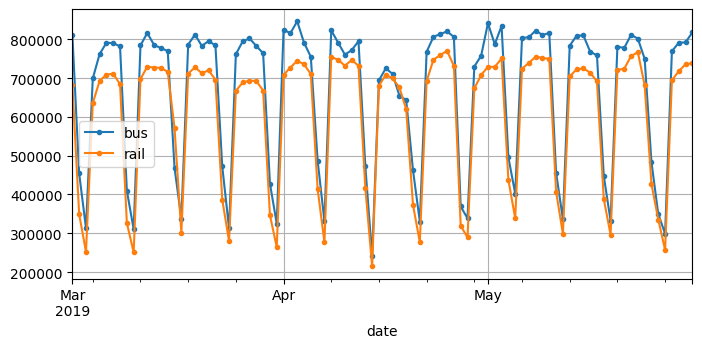

In [9]:
df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

**Todo**: Change the dates in the plot to visualise the figures at other periods. E.g., visualise the data between March 2020 and May 2020. What do you notice? Can you link this to any event you are aware of? 

This is a *time series*, i.e., data with different values at different time steps, with regular intervals. More precisely, this is a *multivariate time series* as we have two values for each time steps (bus and rail riderships). If we were focusing on only one value, this would be a *univariate time series*. We will train models to do prediction of future values based on historical values, i.e., forecasting. Howerver, you can perform other tasks on time series, such as for example classification, imputation and anomaly detection. 

### I.2. Baseline

Before training a RNN on this data, we will build a baseline against which we can compare results. You can notice that the data presents *seasonality*, i.e., a similar pattern is repeated regularly (more people take the train and bus during week days than weekends). In that case, this is clearly a weekly seasonality. The pattern is very strong, and a good baseline could be to forecast the values for a specific day as being the value from 1 week before. This is called *naive forecasting*, i.e., simply copying a value to make the forecast. Usually, naive forecasting is about copying the last known value, but in this case it makes more sense to use the value from one week before due to the string weekly seasonality. 

We can visualise the naive forecasting by plotting the time series (for bus and rail) with its copy, lagged by one week. The `shift` method is used to shift the time series (dotted lines on the top graph). The `diff` method is used to perform *differenciation*, i.e., calculating the difference between the time series and their lagged versions.

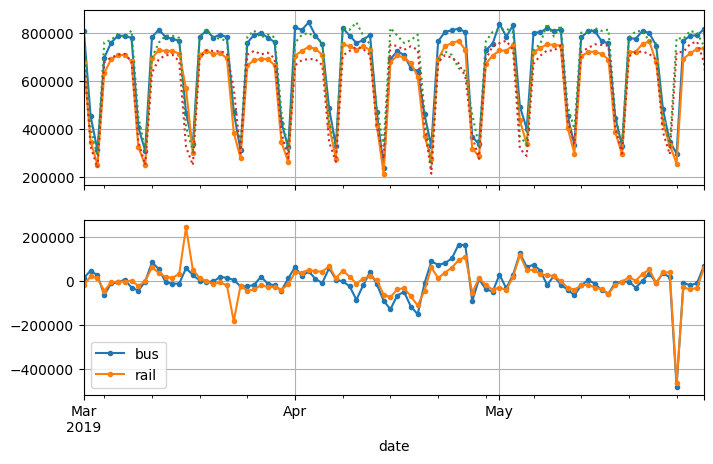

In [21]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged by 7 days
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
axs[0].set_ylim([170_000, 900_000])  # extra code – beautifies the plot
plt.show()

**Todo**: Discuss the results. Does it seems like a good baseline? What could explain the larger differences? Hint, the `day_type` colmun might give some interesting clues. 

When a time series is correlated with a lagged version of itself, we say that they are *autocorrelated*. It looks like it is the case with this time series.

We can also calculate the MAE (Mean Absolute Error) to get a rough idea of the overall error on this arbitrary choosen period of time.

In [11]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

And the MAPE (Mean Absolute Percentage Error).

In [24]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

Over this period of time, the naive forecasting approach gives a 8.3% error for the bus ridership and 9% error for the rail ridership.  
This does not look too bad, but let's see if we can do better with more complicated models, such as RNNs. Note that statistical models are commonly used to make forecasting on time series. Some are especially designed for autocorrelated data. For example, some approaches of the ARMA Model family, such as the ARIMA and SARIMA (for time series with seasonality) could be used here. We will not cover them in this tutorial, but you can look at how to apply them here in Chapter 15 of the "Hands on ML" book and [notebook](https://github.com/ageron/handson-ml3/blob/main/15_processing_sequences_using_rnns_and_cnns.ipynb).



### I.3. Using RNNs for time series forecasting

#### I.3.i. Splitting time series data

To use the time series data to train and make predictions with a RNN, we need to split it into a training, validation and test sets. Splitting a time series into sets is not done in the same way that we have seen before. When dealing with time series, you usually want to split across time (i.e., a period of time for training, and a period of time for validation/testing). However, there are cases for which you could do differently. E.g., if you are looking at stock values over time for a lot of companies, which stocks are likely to be correlated, you could use the stock series of some companies for training, and the ones for other companies for validation/test.

In our case, we decide to design the task such as the model is trained to forecast tomorrow's rail riderships based on the past 8 weeks (56 days) data. The inputs to the model will therefore be sequences of 56 values from time step $t-55$ to $t$. We can use every 56-day window of past data as input for training, and the traget for each window is the value directly following it, such as:
[Input: Day 1 to 56][Target: Day 57]-[Input: Day 58 to 113][Target: Day 114]-[Input: Day 115 to 170][Target: Day 171]-...

Note that we focus only on the rail riderships for the moment, but we will see how we can forecast multivariate time series a bit further.

Before splitting the data that way, we need to split it into a training period, validation period and test period. Let's also scale the values down by factor of one million so that it falls closer to the 0-1 range. It will be working better with the default weight initialisation and learning rate.

In [3]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

To split the data into input sequences and targets as described before, you can directly use the `tf.keras.utlis.timeseries_dataset_from_array()` function provided by TensorFlow/Keras. 

In [4]:
seq_length = 56
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

Note that we specify `shuffle=True` for the training set, to shuffle the training windows (not the instances within them, whihc would not make sense). This is usually leading to better training performances. 

We can now build a RNN based on this data!

#### I.3.ii. Forecasting with a simple RNN

Let's start with a very simple RNN, composed of only 1 recurrent layer containing only 1 recurrent neuron. With TensorFlow/Keras, you can simply add a `SimpleRNN` layer using the Sequential API. The `input_shape` argument is set to `[None, 1]` to specify that the recurrent layer accepts inputs of any length, i.e., `None` meaning here "any size", and with only 1 dimension (univariate time series). 

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

Let's build a utility function we can reuse to train and evaluate different models. Early stopping is added to stop the training if the validation MAE does not improve after 50 epochs. 

In [5]:
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6 # Reverse the scaling 

Let's train and evaluate this simple RNN.

In [21]:
fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 [==============================] - 1s 12ms/step - loss: 0.0606 - mae: 0.2848 - val_loss: 0.0152 - val_mae: 0.1179
Epoch 2/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0135 - mae: 0.1271 - val_loss: 0.0125 - val_mae: 0.1227
Epoch 3/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0124 - mae: 0.1386 - val_loss: 0.0122 - val_mae: 0.1261
Epoch 4/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0123 - mae: 0.1354 - val_loss: 0.0122 - val_mae: 0.1237
Epoch 5/500
33/33 [==============================] - 0s 6ms/step - loss: 0.0123 - mae: 0.1366 - val_loss: 0.0122 - val_mae: 0.1240
Epoch 6/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0122 - mae: 0.1351 - val_loss: 0.0121 - val_mae: 0.1243
Epoch 7/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0122 - mae: 0.1349 - val_loss: 0.0121 - val_mae: 0.1223
Epoch 8/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0121 - 

102870.1588511467

**TODO**: You can see that the MAE is quite high. Discuss reasons why it could be the case.  
Once this is done, you can run the following cell to read more insights.

In [23]:
def read_insights(file):
    with open(file, "r") as file:
        print(file.read())
read_insights("do_not_read.txt")

1. The model only has a single recurrent neuron. Therefore, the only data it can use to make a preduction at each time step is the input value at the current time step and the output of the previous time step. This makes the RNN's memory very limited, with also very few parameters to train. Indeed, as there is only one neuron with two input values, the whole model has only 2 weights and 1 bias, i.e., 3 parameters in total! That is not eneough to make good predictions on this time series. 

2. The scale time series contains values between O and about 1.4. However, the current recurrent layer is using tanh activation function (the default for the SimpleRNN layer). Therefore, the outputs can only be between -1 and 1. It cannot make good predictions for inpiut values whose targets are between 1.0 and 1.4. 


Let's fix this by training a RNN with more recurrent neurons in the hidden layer, and a `Dense` layer on top of it with one neuron (one value to predict) and no activation function (linear output).

In [48]:
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)  # no activation function by default
])

In [49]:
fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

Epoch 1/500
33/33 [==============================] - 1s 11ms/step - loss: 0.0165 - mae: 0.1306 - val_loss: 0.0026 - val_mae: 0.0502
Epoch 2/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0042 - mae: 0.0619 - val_loss: 0.0034 - val_mae: 0.0623
Epoch 3/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0037 - mae: 0.0580 - val_loss: 0.0026 - val_mae: 0.0506
Epoch 4/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0033 - mae: 0.0520 - val_loss: 0.0022 - val_mae: 0.0399
Epoch 5/500
33/33 [==============================] - 0s 6ms/step - loss: 0.0033 - mae: 0.0527 - val_loss: 0.0021 - val_mae: 0.0394
Epoch 6/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0031 - mae: 0.0513 - val_loss: 0.0029 - val_mae: 0.0498
Epoch 7/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0030 - mae: 0.0473 - val_loss: 0.0019 - val_mae: 0.0361
Epoch 8/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0029 - 

30989.885330200195

The validation MAE is much better now!

Let's see if we can do even better by using several recurrent layers (i.e., a Deep RNN). 

#### I.3.iii. Forecasting time series with a Deep RNN

Just like we can stack several fully connected hidden layers in a Deep NN, we can stack several recurrent layers to create a Deep RNN. The following code defines a RNN with 3 hidden recurrent layers and 1 output full connected layer.  

In [27]:
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

Note that you need to set `return_sequences` to `True` in the hidden layers, except the last one. If you do not do this, the two first hidden layers will only pass the output of the last time step to the next layer, which is not what you want. This should only be the case for the last hidden layer which feeds into the output layer to make the final prediction.

Let's train this Deep RNN. 

In [28]:
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

Epoch 1/500
33/33 [==============================] - 3s 30ms/step - loss: 0.1264 - mae: 0.3613 - val_loss: 0.0272 - val_mae: 0.1535
Epoch 2/500
33/33 [==============================] - 1s 19ms/step - loss: 0.0171 - mae: 0.1595 - val_loss: 0.0157 - val_mae: 0.1301
Epoch 3/500
33/33 [==============================] - 1s 19ms/step - loss: 0.0160 - mae: 0.1549 - val_loss: 0.0161 - val_mae: 0.1170
Epoch 4/500
33/33 [==============================] - 1s 19ms/step - loss: 0.0151 - mae: 0.1489 - val_loss: 0.0158 - val_mae: 0.1116
Epoch 5/500
33/33 [==============================] - 1s 19ms/step - loss: 0.0138 - mae: 0.1410 - val_loss: 0.0127 - val_mae: 0.1536
Epoch 6/500
33/33 [==============================] - 1s 20ms/step - loss: 0.0130 - mae: 0.1323 - val_loss: 0.0066 - val_mae: 0.0894
Epoch 7/500
33/33 [==============================] - 1s 21ms/step - loss: 0.0077 - mae: 0.0971 - val_loss: 0.0046 - val_mae: 0.0714
Epoch 8/500
33/33 [==============================] - 1s 21ms/step - loss: 0.

31901.47876739502

The validation MAE is higher than with the previous model that was using only 1 hidden layer. This shows that this model might be to large for the task at hand, and shallower RNN is best suited here. 

#### I.3.iv. Forecasting multivariate Time Series

As we have discussed in previous lectures and tutorials, one of the strength of neural networks is their flexibility. For RNNs, it is easy to have them deal with multivariate time series, without modifying their architecture. For the example we are working with now, let's try to forecast the rail ridership using both the bus and rail data, as well as the day type! To do this, we need to prepare the data a little bit differently than before, but we will use the same model architecture. 

The following code creates a Pandas DataFrame with 3 attributes: the bus and rail time series, and the day type for the next day (which might be useful to do better predictions). To get the next day type, we can just shift the `day_type` values by one. We can do this as we always know if tomorrow's day will be a weekday, a weekend or a holiday. 

In [35]:
df_mulvar = df[["bus", "rail"]] / 1e6  # use both bus & rail series as input
df_mulvar["next_day_type"] = df["day_type"].shift(-1)  # we know tomorrow's type
df_mulvar = pd.get_dummies(df_mulvar, dtype = np.float32)  # one-hot encode the day type

The data is then split the DataFrame in train, validation and test data based on periods of time.

In [36]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

You can then create the train and validation datasets as we did before (windows of 56 days for training and the following day for validation).

In [41]:
seq_length = 56
train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),  # use all 5 columns as input
    targets=mulvar_train["rail"][seq_length:],  # forecast only the rail series
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

Finally, you can use a 1-layer RNN as we did earlier, to train a model on this multivariate data.

In [39]:
mulvar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(1)
])

In [40]:
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.05)

Epoch 1/500
33/33 [==============================] - 1s 13ms/step - loss: 0.0257 - mae: 0.1554 - val_loss: 0.0016 - val_mae: 0.0447
Epoch 2/500
33/33 [==============================] - 0s 6ms/step - loss: 0.0024 - mae: 0.0509 - val_loss: 0.0010 - val_mae: 0.0337
Epoch 3/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0017 - mae: 0.0415 - val_loss: 7.0860e-04 - val_mae: 0.0278
Epoch 4/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0016 - mae: 0.0384 - val_loss: 7.0765e-04 - val_mae: 0.0277
Epoch 5/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0014 - mae: 0.0362 - val_loss: 0.0012 - val_mae: 0.0377
Epoch 6/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0015 - mae: 0.0383 - val_loss: 5.9136e-04 - val_mae: 0.0239
Epoch 7/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0013 - mae: 0.0354 - val_loss: 7.4601e-04 - val_mae: 0.0283
Epoch 8/500
33/33 [==============================] - 0s 7ms/step -

21430.67494034767

**TODO**: Is this model doing better than the previous ones we trained on univariate data? 

So far, your models only predict the rail ridership, but you can predict the bus and train ridership at the same time! To do so, you just need to modify the `targets` argument when creating the datasets with the `timeseries_dataset_from_array()` function.

In [42]:
seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets=mulvar_train[["bus", "rail"]][seq_length:],  # 2 targets per day
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets=mulvar_valid[["bus", "rail"]][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

You also need to change the number of neurons in the output layer to 2, as you are now predicting 2 values.

In [91]:
multask_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(2)
])

In [46]:
fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 [==============================] - 1s 11ms/step - loss: 0.0515 - mae: 0.2283 - val_loss: 0.0032 - val_mae: 0.0601
Epoch 2/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0046 - mae: 0.0682 - val_loss: 0.0014 - val_mae: 0.0361
Epoch 3/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0032 - mae: 0.0532 - val_loss: 0.0016 - val_mae: 0.0417
Epoch 4/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0029 - mae: 0.0506 - val_loss: 0.0014 - val_mae: 0.0389
Epoch 5/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0026 - mae: 0.0485 - val_loss: 0.0015 - val_mae: 0.0414
Epoch 6/500
33/33 [==============================] - 0s 6ms/step - loss: 0.0023 - mae: 0.0465 - val_loss: 0.0011 - val_mae: 0.0346
Epoch 7/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0022 - mae: 0.0454 - val_loss: 0.0011 - val_mae: 0.0343
Epoch 8/500
33/33 [==============================] - 0s 7ms/step - loss: 0.0021 - 

26806.700974702835

The MAE value you get at the end of training is the average validation MAE for the 2 outputs. You can run the following cell to break this down into validation MAE for the bus and rail seperately.

In [47]:
Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(["bus", "rail"]):
    mae = 1e6 * tf.keras.metrics.mean_absolute_error(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 [==============================] - 0s 2ms/step
bus 27401
rail 26211


#### I.3.v. Forecasting Several Time Steps Ahead

What if you want to predict ridership number not only for the next day, but for several days ahead? The simplest approach is to use one of the models we trained to predict ridership for the next day, and add the value to the input, acting like if it had actually occured. Let's do this with the `univar_model` trained previously to predict the rail time series, and predict rail ridership for 14 days ahead, using the rail time series validation dataset. 

In [50]:
X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 [==============================] - 0s 16ms/step


Run the following cell to visualise a plot of the predicted values alongside the true values.

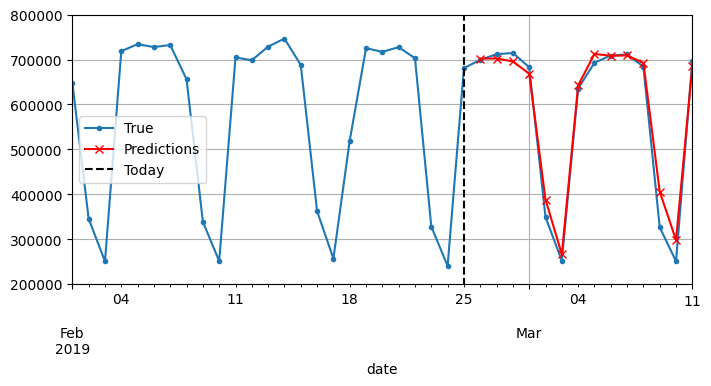

In [51]:
# The forecasts start on 2019-02-26, as it is the 57th day of 2019, and they end
# on 2019-03-11. That's 14 days in total.
Y_pred = pd.Series(X[0, -14:, 0],
                   index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot(
    label="True", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="Predictions", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="Today")
ax.set_ylim([200_000, 800_000])
plt.legend(loc="center left")
plt.show()

It does not look too bad! However, note that if the model makes an error at one time step, it will impact the next forecasts. Errors tend to accumulate and therefore this approach is preferable if you want to only predict a small number of steps ahead.  
Another option is to train to your RNN to predict the next $x$ steps (here 14) at once. We will not cover that here, but you can look at [Chapter 15 notebook](https://github.com/ageron/handson-ml3/blob/main/15_processing_sequences_using_rnns_and_cnns.ipynb) for the "Hands on ML" book for the implmentation of this approach.

#### I.3.vi. LSTMs and GRUs

We have seen in the lecture that vanilla RNNs, such as the ones we just trained, are not good with long sequences as they suffer greatly from the vanishing gradients problem. LSTM and GRU are two extensions of the RNN architecture, better at handling long sequences. 

Building a LSTM or a GRU with Keras/TensorFlow is very simple. You can directly add a `LSTM` or `GRU` layer with the Sequential API, just as shown below. 

In [59]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

In [60]:
gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

**TODO (optional)**: You can try to train these models if you would like to, but their performance are not likely to be much better than the vanilla RNN we trained before. This is because we are using rather short sequences for training (56 data points). You can try to compare these different models with training on longer sequences, and see if you can observe a difference then.

Else, you can directly start the next part, in which we will use GRU to generate text. 

## II. Generating text with Char-RNN Model

In this part, you will download and pre-process text data from a dataset of Shakespeare's works, and train a char-RNN to perform text generation in thje style of Shakespeare. 

### II.1. Building the Shakespeare's works dataset

#### II.1.i. Downloading the data

Let's start by downloading the Shakespeare's works dataset, from Andrej Karpathy's char-rnn GitHub project.

In [3]:
shakespeare_url = "https://homl.info/shakespeare"  # shortcut URL
filepath = tf.keras.utils.get_file("shakespeare.txt", shakespeare_url)
with open(filepath) as f:
    shakespeare_text = f.read()

And let's print the first few lines.

In [4]:
print(shakespeare_text[:80])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.


**TODO**: What Shakespeare's work are these lines taken from? (Not need to explore the data for this, you can just Google it).

#### II.1.ii. Pre-processing the text data

To use text data to train a model, we need to apply a specific type of pre-processing. Text data has to be converted into a numerical representation that can be handled by the model. There are several ways to do this. Here, we will use text vectorisation. Text vectorisation is used to map text to corresponding numerical vectors (implemented as tensors) which can be used to train a model. For this task, we want to train a model to generate text, character by character. Therefore, we need to encode each character in the data as a separate integer value, called an integer *token*.  
Let's have a look at all the individual characters appearing in the data, by running the following cell.

In [5]:
indiv_chars = "".join(sorted(set(shakespeare_text.lower())))

In [6]:
indiv_chars

"\n !$&',-.3:;?abcdefghijklmnopqrstuvwxyz"

In [7]:
len(indiv_chars)

39

There are 39 different characters (also called string tokens) in the dataset, which means 39 integer tokens are needed to encode each individual character.

With Keras/TensorFlow, we can use the `TextVectorization` layer to perform this. You can read more details about this layer in the [TensorFlow documentation](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization).

In [8]:
text_vec_layer = tf.keras.layers.TextVectorization(split="character",
                                                   standardize="lower")
text_vec_layer.adapt([shakespeare_text])
encoded = text_vec_layer([shakespeare_text])[0]

By setting `split` to `"character"`, we get a character-level encoding, i.e., each character is encoded with a specific numerical value. This will allow us to train a model to generate text character by character. The text is also converted to lowercase (before encoding) as we set `standardize` to `"lower"`. This is done to simplify the task (else the vocabulary would be larger).  
The `adapt()` method is run to build a vocabulary of all string tokens (here, character) seen in the dataset, i.e., it maps one integer token to each character seen in the dataset. 

**Note**: The integer used as tokens for the encoding range from 2 to the number of string tokens in the dataset plus 2 (i.e., 2 to 41 here). The `TextVectorization` layer reserves the value 0 for padding tokens, and the value 1 for unknown characters (in case you get new characters when using your models, compared to the vocabulary seen in training). Padding tokens are used to pad shorter sequences so that all sequences have the same length (it is not used in this task). 

Let's have a look at the first 80 encoded characters.

In [9]:
print(encoded[:80])

tf.Tensor(
[21  7 10  9  4  2 20  7  4  7 37  3 11 25 12 23  3 21  5 10  3  2 18  3
  2 24 10  5 20  3  3 14  2  6 11 17  2 21 15 10  4  8  3 10 19  2  8  3
  6 10  2 16  3  2  9 24  3  6 26 28 12 12  6 13 13 25 12  9 24  3  6 26
 19  2  9 24  3  6 26 28], shape=(80,), dtype=int64)


**Todo**: Can you identify the mapping between some characters in the original text and the corresponding integer token?

Next, we drop tokens 0 (pad) and 1 (unknown), which we will not use (this will modify the mapping you identified just before), and store the vocabulary size (i.e., number of tokens) and dataset size. 

In [10]:
encoded -= 2  # drop tokens 0 (pad) and 1 (unknown)
n_tokens = text_vec_layer.vocabulary_size() - 2  # number of distinct chars = 39
dataset_size = len(encoded)  # total number of chars = 1,115,394

In [11]:
n_tokens

39

The number of tokens is consistent with what we found previously.

In [12]:
dataset_size

1115394

We have a total of 1 115 394 encoded characters in the dataset.

#### II.2.iii. Creating the dataset

Next, we create a helper function to turn this very long sequence into a dataset of windows that we can use to train a RNN (just like we did for the time series previously). We are not reusing the `timeseries_dataset_from_array()` fucntion, but the following function does a similar job. The inputs for a window will be a sequence of size `length`, and the corresponding target will be another sequence of size `length`, which is the same as the input but shifted by one time step ahead. For example, if we decide to use sequences with a length of 17 characters, one sample of the dataset may be the 17-character sequence "to be or not to b" and the corresponding target would be the 17-character sequence "o be or not to be". 

**Note**: The total length of the sequence used for this sample would be `length + 1` (i.e., 17 + 1 = 18). 

In [13]:
def to_dataset(sequence, length, shuffle=False, seed=None, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(sequence)
    ds = ds.window(length + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda window_ds: window_ds.batch(length + 1))
    if shuffle:
        ds = ds.shuffle(100_000, seed=seed)
    ds = ds.batch(batch_size)
    return ds.map(lambda window: (window[:, :-1], window[:, 1:])).prefetch(1)

This function:
- takes a sequence as input (i.e., the full encoded text), and creates a dataset containing all the windows of the desired length.
- increases the length by one, since we need the next character for the target.
- shuffles the windows (only if `shuffle=False`), batches them, splits them into input/output pairs and activate prefetching.

Prefetching is used to accelerate training. You can read more about it in the [TensorFlow documentation](https://www.tensorflow.org/guide/data_performance#prefetching).

You can run the following cell to see this function in action on a very small and simple dataset.

In [14]:
# There's just one sample in this dataset: the input represents "to b" and the
# output represents "o be"
list(to_dataset(text_vec_layer(["To be"])[0], length=4))

[(<tf.Tensor: shape=(1, 4), dtype=int64, numpy=array([[ 4,  5,  2, 23]], dtype=int64)>,
  <tf.Tensor: shape=(1, 4), dtype=int64, numpy=array([[ 5,  2, 23,  3]], dtype=int64)>)]

Finally, run the following cell to split the dataset into training set, validation set and test set. As there are more than 1M charaters in the dataset, we decide to use roughly 90% of the text for training, 5% for validation, and 5% for testing.

In [92]:
length = 100
train_set = to_dataset(encoded[:1_000_000], length=length, shuffle=True)
valid_set = to_dataset(encoded[1_000_000:1_060_000], length=length)
test_set = to_dataset(encoded[1_060_000:], length=length)

We can now use this dataset to train a char-RNN (i.e., a RNN to generate text characters)!

### II.2. Building and Training a Char-RNN Model

The dataset is quite large and modelling language is not an easy task, so we need more than a RNN with a few recurrent neurons. Let's use a GRU layer (to better handle large senquences), with 128 units. You can try to tweak this number of units or the number of layers later if you would like to (but it is already long to train).  

In [93]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=n_tokens, output_dim=16),
    tf.keras.layers.GRU(128, return_sequences=True),
    tf.keras.layers.Dense(n_tokens, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model_ckpt = tf.keras.callbacks.ModelCheckpoint(
    "my_shakespeare_model", monitor="val_accuracy", save_best_only=True)

Let's analyse the model's architecture:
- The model first uses an `Embedding` layer. Embeddings are a lower-dimentional representations of a higher-dimentional data. The idea is to learn a compressed representation of the data, instead of using more direct encodings such as one-hot encoding for example. Imagine you want to represent a categorical attribute with 20 000 possible categories. With one-hot encoding, it would produce a 20 000-dimentional sparse vector (i.e., containing mostly zeroes). In contrast, an embbedding would learn a lower-dimentional (e.g., 100-dimentional) dense vector. This is used a lot when manipulating language data, as the vocabulary (i.e., the possible values a token can take, e.g., every possible words in the English language) is usually extremely large. Embeddings are a convenient way to represent text data in a low-dimentional dense vector for training models. You can read more about embeddings in chapter 13 of the "Hands on ML" book. Here, you can see that we set the embedding layer will learn a representation that will reduce the dimension of the input from 39 (number of possible tokens) to 16 (output dimension). 
- Then, the model uses a hidden `GRU` layer with 128 units.
- Finally, the output layer is a `Dense` layer with 39 neurons (number of possible tokens) with a softmax activation function as each of the 39 classes are mutually exclusive (i.e., the predicted character is a unique character). The softmax layer will return 39 probabilities summing to 1 for each time step.

You can also see that the model is computed with `sparse_categorical_crossentropy` loss and the Nadam optimiser. The [Nadam optimiser](https://cs229.stanford.edu/proj2015/054_report.pdf) is an extension of the Adam optimiser, using Nesterov momentum.

**WARNING - READ BEFORE EXECUTING THE NEXT CELL**: Training this model on Colab with a GPU will take 1 to 2 hours. You can run it for less epochs if you want to reduce this time, but the performances will probably be lower. If you are diconnected from the Colab session during the training, you need to reconnect quickly, or else the Colab runtime will be deleted and you will lose the training you have already done. On a CPU, the next cell may take over 24h to run.  
If you don't want to wait for the training to complete, you can skip the next cell and directly download the trained network.

In [ ]:
# WARNING: This cell will take 1 to 2h to run on a GPU, and may take over 24h to run on a CPU
# Uncomment the next 2 lines if you wish to execute the training
# history = model.fit(train_set, validation_data=valid_set, epochs=10,
#                    callbacks=[model_ckpt])

You can skip the next cell too if you did not train the model yourself.  

If you trained the model with the previous cell, you need to run the next cell as well, to include the pre-processing layer in the final model, and removing the padding and unknown tokens. We need to do this as we did not include this in the model builder, but this needs to be applied to new sequences we want to make predictions for.

In [17]:
shakespeare_model = tf.keras.Sequential([
    text_vec_layer,
    tf.keras.layers.Lambda(lambda X: X - 2),  # no <PAD> or <UNK> tokens
    model
])

The following code will download the trained model's weights. Uncomment the last line if you want to use it instead of the model trained above.

In [20]:
# Run this code (with the last lined uncommented) if you want to download and use the trained char-RNN model
url = "https://github.com/ageron/data/raw/main/shakespeare_model.tgz"
path = tf.keras.utils.get_file("shakespeare_model.tgz", url, extract=True)
model_path = Path(path).with_name("shakespeare_model")
shakespeare_model = tf.keras.models.load_model(model_path)

### II.3. Making predictions with the char-RNN model

#### II.3.i. Predict the next character in a text sequence

Let's use the model to predict the next character in a text sequence! Remember that the output layer uses a softmax activation fucntion, which output 39 probabilities, one for each possible integer token. If we apply the `argmax()` function to the output of the model, we will select the integer token with the highest probability as the prediction. We can then map this selected integer token back to the corresponding character using the `get_vocabulary()` method of the pre-processing layer used to encode the text data into integer tokens. 

In [76]:
y_proba = shakespeare_model.predict(["To be or not to b"])[0, -1]
y_pred = tf.argmax(y_proba)  # choose the most probable character ID
text_vec_layer.get_vocabulary()[y_pred + 2] # + 2 as original mapping includes the 2 tokens we removed (padding and unknown)

1/1 [==============================] - 0s 170ms/step


'e'

The model predicted the next character correctly!

**TODO**: Try to change the input text for the prediction and see what the model outputs!

#### II.3.ii. Predict new chunks of text

What if we want to generate chunks of text instead of only the next character? A simple approach would to predict the next character as previously, then add it at the end of the input sequence, use this new sequence predict another character, and so on. This is called *greedy decoding*. However, this usually leads in practice to the same words being repeated over and over again, as we are using argmax to select the next character with the highest probability. Instead, we can sample randomly the next character with a probability equal to the estimated probabilities given by the softmax layer. This leads to more diverse text being generated. We can use the `tf.random.categorical()` function  which samples random class indices given the class log probabilities (logits). 

Let's define a helper function to select the next character in a sequence using the probabilities given by the model. We include a `temperature` argument which can be tweaked to control the probabilities to select characters. A temperature close to 0 favors high-probability characters (as predicted by the model), while a high temperature gives all characters an equal probability to be picked. A higher temperature will typically lead to more diverse and creative text than a lower temperature. 

In [82]:
def next_char(text, temperature=1, verbose = "auto"):
    y_proba = shakespeare_model.predict([text], verbose = verbose)[0, -1:]
    rescaled_logits = tf.math.log(y_proba) / temperature
    char_id = tf.random.categorical(rescaled_logits, num_samples=1)[0, 0]
    return text_vec_layer.get_vocabulary()[char_id + 2]

Let's define another helper function which calls the `next_char()` function repeatedly to generate a text of length specified in the argument `n_chars`.

In [83]:
def extend_text(text, n_chars=50, temperature=1, verbose = "auto"):
    for _ in range(n_chars):
        text += next_char(text, temperature, verbose)
    return text

We can now generate text using the `extend_text()` function! 

In [90]:
print(extend_text("To be or not to be", temperature=0.01))

1/1 [==============================] - 0s 110ms/step
To be or not to be the duke
as it is a proper strange death,
and the


**TODO**: You can play with the text generation. Try to modify the temperature to see how it modifies the output. For example, what happens with temperature equal to 1 and 100?  
You can also modify the `n_chars` parameter to generate longer text. Feel also free to change the input text sequence!  
Note that you can set the verbosity mode to "silent" by setting the `verbose` parameter to 0, if you do not want to see the progress bar  for each prediction step. 

Does it looks like convincing Shakespearian text to you? The quality of the generation can be improved with multiple approaches. You could try to add more GRU layers, with more GRU units per layer, train for longer, and adding some regularisation if necessary. Also, you current char-RNN model is not capable of learning patterns longer than the `length` parameter we set to 100 when preparing the dataset. This might partially explain some repeatitive patterns you might have noticed when playing with the text generation. Therefore, you could set `length` to a larger value, but it will make the training longer, and even LSTM and GRU cannot handle sequences that are too long. An alternative approach is to use a stateful RNN. We do not cover it in this tutorial, but it is covered in Chapter 16 of the "Hands on ML" book. 

#### PyTorch note on char-RNN and the RNN class
If you want to see how to build and train a char-RNN in PyTorch and use it to classify name's provenance, you can have a look a the [NLP From Scratch: Classifying Names with a Character-Level RNN PyTorch tutorial](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html). This tutorial implements a RNN from scratch. 

PyTorch also provides [Recurrent layers classes](https://pytorch.org/docs/stable/nn.html#recurrent-layers), similar to what we used previously with Keras/TensorFlow.

## III. Using Transformer-based models with the Hugging Face Transformers library

In [96]:
# To install libraries needed for this part on Colab
if "google.colab" in sys.modules:
    %pip install -q -U transformers
    %pip install -q -U datasets

The tutorial is already long with the 2 first parts, so we decided rather not to include coding the Transformer architecture from (almost) scratch in this thrid part. Instead, you will load and use pre-trained Transformer models to play with them directly. However, the code for the Transformer architecture is described in details in Chapter 16 of the "Hands on ML" book, and available in the [Chapter 16 notebook](https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb). We really encourage you to have a look at it and try to understand the code in the light of the different parts we described during the lecture.  
You can also have a look at the [DataCamp tutorial on "Building a Transformer with PyTorch"](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch) if you prefer to use PyTorch.

Hugging Face is an AI company which is providing one of the biggest repository of models available in open-source. They maintain the Transformers library, which allow you to load and use a large variety of pretrained models for natural language processing (NLP), computer vision, and audio and speech processing tasks. You might learn more about some of these models in the second part of the course. The Transformers library give you access to a lot of models based on the Transformer architecture, but also to non-Transformer models like Convolutional Neural Networks (CNNs) for computer vision tasks (we will talk about CNNs next week).  
On top of this, the library support multiple frameworks, including TensorFlow and PyTorch.

Let's have a look at using some model for NLP tasks such as sentiment analysis and translation. The simplest way to use this library is to use the `transformers.pipeline()` function. You just need to specify the type of task you want to perform, and eventually a specific pre-trained model you want to use (else it will use a default one), and it downloads the model which you can use directly, or fine-tune on your own data (you will see this in the transfer learning lectures). 
You can read more about it at the [Hugging Face documentation](https://huggingface.co/docs/transformers/en/main_classes/pipelines). 

In [95]:
from transformers import pipeline

C:\Users\thoma\Documents\WorkUoA\Teaching\2024\S1\CS714\Tutorials\compsci714\cs714-env\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
C:\Users\thoma\Documents\WorkUoA\Teaching\2024\S1\CS714\Tutorials\compsci714\cs714-env\Lib\site-packages\transformers\utils\generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


First, let's load a model to perform some sentiment analysis (i.e., abel text according to some polarity like positive or negative). 

In [142]:
classifier = pipeline("sentiment-analysis")  # many other tasks are available

No model was supplied, defaulted to distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


We can now use the loaded model to perform predictions on input text sequences.

In [143]:
classifier("I love COMPSCI 714.")

[{'label': 'POSITIVE', 'score': 0.9996547698974609}]

In [145]:
classifier("I am tired today.")

[{'label': 'NEGATIVE', 'score': 0.9997768998146057}]

**Important note**: Sentiment analysis predictions can be very biased, and output questionnable results. Try to play with it to see if you can generate some questionnable predictions.  
We will not go more in details into sentiment analysis in this tutorial, but such biases can come fro mthe training data itself (e.g., some topics getting more negative mentions than others), or the labelling (there are plenty of cases where it is hard to objectively say if a sentence if carrying a "positive" or "negative" sentiment). 

Let's now try a translation task with the *google-t5/t5-small* language model.

In [148]:
translator = pipeline(task="translation_en_to_fr", model="google-t5/t5-small")

In [132]:
text = "translate English to French: Good day!"
translator(text)

[{'translation_text': 'Bonne journée!'}]

This model's version is good for very simple translation, but it shows some limitations for slightly more complicated ones.

Here are some links to some more examples of the `pipeline()` function being [used for different tasks](https://huggingface.co/docs/transformers/en/task_summary), a [list of available models](https://huggingface.co/models) and the [list of available tasks](https://huggingface.co/tasks). Note that some models might require specific access rights, and also specific tools to be installed, but there is already a bunch of things you can do without worrying about that. 

**To continue**: Have fun trying different things with the Hugging Face Transformers library, and have a look at the Transformer architecture code!